Choose Mode:
1 -> Image Detection
2 -> Video Detection

0: 448x640 1 car, 47.9ms
Speed: 6.0ms preprocess, 47.9ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
test1.jpg -> Vehicles detected: 1


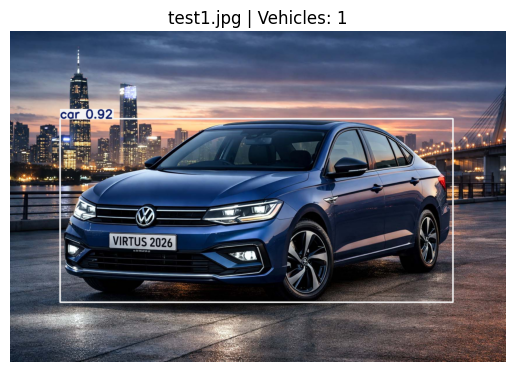


0: 384x640 1 car, 53.8ms
Speed: 1.1ms preprocess, 53.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
test2.jpg -> Vehicles detected: 1


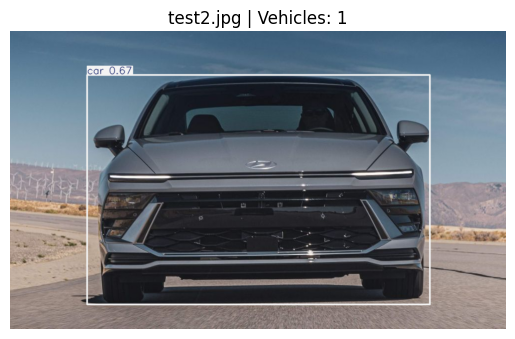

In [1]:
# ---------------- VEHICLE DETECTION (FINAL CLEAN VERSION) ----------------

from ultralytics import YOLO
import cv2
import os
from matplotlib import pyplot as plt

# Load YOLO model
model = YOLO("yolov8n.pt")

# Vehicle classes (COCO dataset)
# 2=car, 3=motorbike, 5=bus, 7=truck
VEHICLE_CLASSES = [2, 3, 5, 7]


# ---------------- IMAGE DETECTION ----------------
def detect_images(folder="images"):

    if not os.path.exists(folder):
        print(f"Folder '{folder}' not found")
        return

    os.makedirs("outputs", exist_ok=True)

    for file in os.listdir(folder):

        if file.endswith((".jpg", ".png", ".jpeg")):

            path = os.path.join(folder, file)
            img = cv2.imread(path)

            results = model(img, conf=0.5)

            vehicle_count = 0

            for r in results:

                for box in r.boxes:
                    cls = int(box.cls[0])
                    if cls in VEHICLE_CLASSES:
                        vehicle_count += 1

                output = r.plot()

            print(f"{file} -> Vehicles detected: {vehicle_count}")

            # Show image (Notebook safe)
            plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
            plt.title(f"{file} | Vehicles: {vehicle_count}")
            plt.axis("off")
            plt.show()

            # Save output image
            save_path = os.path.join("outputs", f"output_{file}")
            cv2.imwrite(save_path, output)

            # Save log (FIXED UTF-8)
            with open("log.txt", "a", encoding="utf-8") as f:
                f.write(f"{file} -> {vehicle_count} vehicles\n")


# ---------------- VIDEO DETECTION ----------------
def detect_video(video_path="test.mp4"):

    if not os.path.exists(video_path):
        print("Video file not found")
        return

    cap = cv2.VideoCapture(video_path)

    frame_count = 0

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, conf=0.5)

        vehicle_count = 0

        for r in results:

            for box in r.boxes:
                cls = int(box.cls[0])
                if cls in VEHICLE_CLASSES:
                    vehicle_count += 1

            output = r.plot()

        # Show few frames only (avoid lag)
        if frame_count % 30 == 0:
            plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
            plt.title(f"Frame {frame_count} | Vehicles: {vehicle_count}")
            plt.axis("off")
            plt.show()

        frame_count += 1

        if frame_count > 120:  # limit frames
            break

    cap.release()
    print("Video processing completed")


# ---------------- MAIN ----------------
print("Choose Mode:")
print("1 -> Image Detection")
print("2 -> Video Detection")

choice = input("Enter choice (1/2): ")

if choice == "1":
    detect_images("images")

elif choice == "2":
    detect_video("test.mp4")

else:
    print("Invalid choice")